In [1]:
!wget https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
!unzip jena_climate_2009_2016.csv.zip

import os
import numpy as np

fname = "jena_climate_2009_2016.csv"

with open(fname) as f:
    data = f.read()

lines = data.split("\n")
header = lines[0].split(",")
lines = lines[1:]

temperature = np.zeros((len(lines),))
raw_data = np.zeros((len(lines), len(header) - 1))

for i, line in enumerate(lines):
    values = [float(x) for x in line.split(",")[1:]]
    temperature[i] = values[1]
    raw_data[i, :] = values[:]


num_train_samples = int(0.5 * len(raw_data))
num_val_samples = int(0.25 * len(raw_data))
num_test_samples = len(raw_data) - num_train_samples - num_val_samples


mean = raw_data[:num_train_samples].mean(axis=0)
raw_data -= mean
std = raw_data[:num_train_samples].std(axis=0)
raw_data /= std


from tensorflow import keras

sampling_rate = 6
sequence_length = 120
delay = sampling_rate * (sequence_length + 24 - 1)
batch_size = 256

train_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=0,
    end_index=num_train_samples)

val_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples,
    end_index=num_train_samples + num_val_samples)

test_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples + num_val_samples)

--2026-04-02 02:09:44--  https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
Resolving s3.amazonaws.com (s3.amazonaws.com)... 3.5.13.212, 16.182.73.144, 54.231.166.104, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|3.5.13.212|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 13565642 (13M) [application/zip]
Saving to: ‘jena_climate_2009_2016.csv.zip’

jena_climate_2009_2 100%[===================>]  12.94M  26.0MB/s    in 0.5s    

2026-04-02 02:09:45 (26.0 MB/s) - ‘jena_climate_2009_2016.csv.zip’ saved [13565642/13565642]

Archive:  jena_climate_2009_2016.csv.zip
  inflating: jena_climate_2009_2016.csv  
  inflating: __MACOSX/._jena_climate_2009_2016.csv  


In [2]:
from tensorflow.keras import layers

inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Flatten()(inputs)
x = layers.Dense(16, activation="relu")(x)
outputs = layers.Dense(1)(x)
model_dense = keras.Model(inputs, outputs)

model_dense.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

history_dense = model_dense.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset
)

val_dense = min(history_dense.history["val_mae"])
test_dense = model_dense.evaluate(test_dataset)[1]

print("Dense Val MAE:", val_dense)
print("Dense Test MAE:", test_dense)

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 53s 63ms/step - loss: 13.6870 - mae: 2.8498 - val_loss: 11.9930 - val_mae: 2.7435
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 51s 62ms/step - loss: 9.3110 - mae: 2.3988 - val_loss: 10.2743 - val_mae: 2.5351
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 51s 62ms/step - loss: 8.6242 - mae: 2.3130 - val_loss: 11.5500 - val_mae: 2.7041
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 51s 62ms/step - loss: 8.1500 - mae: 2.2525 - val_loss: 10.4224 - val_mae: 2.5644
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 52s 63ms/step - loss: 7.8096 - mae: 2.2062 - val_loss: 10.6231 - val_mae: 2.5855
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 51s 62ms/step - loss: 7.5423 - mae: 2.1706 - val_loss: 13.7675 - val_mae: 2.9688
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 52s 63ms/step - loss: 7.3451 - mae: 2.1415 - val_loss: 10.8146 - val_mae: 2.6101
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 51s 62ms/step - loss: 7.1917 - mae: 2.1207 - val_loss: 10.8118 - val_mae: 2.6072
Epoch 9/10
819/819 ━━━━━━━━━━━━

In [3]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.LSTM(16)(inputs)
outputs = layers.Dense(1)(x)
model_lstm = keras.Model(inputs, outputs)

model_lstm.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

history_lstm = model_lstm.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset
)

val_lstm = min(history_lstm.history["val_mae"])
test_lstm = model_lstm.evaluate(test_dataset)[1]

print("LSTM Val MAE:", val_lstm)
print("LSTM Test MAE:", test_lstm)

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 97s 116ms/step - loss: 35.4225 - mae: 4.3468 - val_loss: 11.7836 - val_mae: 2.6203
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 95s 115ms/step - loss: 10.9762 - mae: 2.5720 - val_loss: 9.9335 - val_mae: 2.4569
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 96s 116ms/step - loss: 9.7709 - mae: 2.4369 - val_loss: 9.9130 - val_mae: 2.4496
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 94s 114ms/step - loss: 9.1299 - mae: 2.3601 - val_loss: 9.6891 - val_mae: 2.4076
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 96s 117ms/step - loss: 8.7491 - mae: 2.3111 - val_loss: 9.9352 - val_mae: 2.4401
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 98s 119ms/step - loss: 8.4702 - mae: 2.2769 - val_loss: 9.6722 - val_mae: 2.4105
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 95s 116ms/step - loss: 8.2571 - mae: 2.2496 - val_loss: 9.7523 - val_mae: 2.4172
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 97s 118ms/step - loss: 8.0954 - mae: 2.2279 - val_loss: 9.5052 - val_mae: 2.3871
Epoch 9/10
819/819 ━━━━━━━━━━

In [4]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.GRU(32, return_sequences=True)(inputs)
x = layers.GRU(32)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)
model_gru = keras.Model(inputs, outputs)

model_gru.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

history_gru = model_gru.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset
)

val_gru = min(history_gru.history["val_mae"])
test_gru = model_gru.evaluate(test_dataset)[1]

print("GRU Val MAE:", val_gru)
print("GRU Test MAE:", test_gru)

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 247s 297ms/step - loss: 24.2333 - mae: 3.6195 - val_loss: 9.5313 - val_mae: 2.3946
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 244s 298ms/step - loss: 13.4471 - mae: 2.8347 - val_loss: 8.7731 - val_mae: 2.2988
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 241s 294ms/step - loss: 12.4772 - mae: 2.7360 - val_loss: 8.8341 - val_mae: 2.3051
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 263s 295ms/step - loss: 11.7476 - mae: 2.6545 - val_loss: 8.9960 - val_mae: 2.3277
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 240s 292ms/step - loss: 11.0621 - mae: 2.5809 - val_loss: 9.5262 - val_mae: 2.3948
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 243s 296ms/step - loss: 10.4072 - mae: 2.5020 - val_loss: 9.7434 - val_mae: 2.4421
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 240s 293ms/step - loss: 9.8626 - mae: 2.4341 - val_loss: 10.0848 - val_mae: 2.4671
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 243s 296ms/step - loss: 9.3972 - mae: 2.3757 - val_loss: 10.1183 - val_mae: 2.4657
Epoch 9/10
819/8

In [5]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Dense", "LSTM", "Stacked GRU"],
    "Val MAE": [val_dense, val_lstm, val_gru],
    "Test MAE": [test_dense, test_lstm, test_gru]
})

results

,Model,Val MAE,Test MAE
0,Dense,2.535091,3.022121
1,LSTM,2.368347,2.656712
2,Stacked GRU,2.298814,2.752991


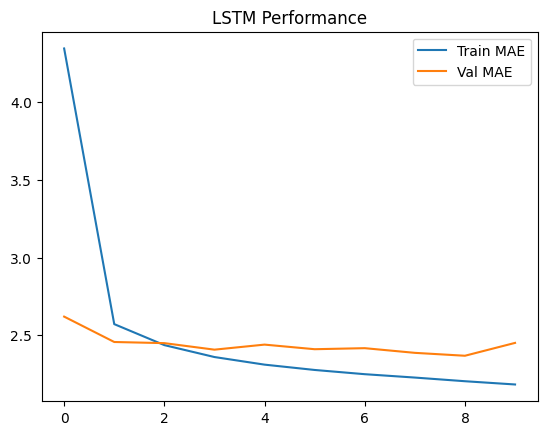

In [6]:
import matplotlib.pyplot as plt

plt.plot(history_lstm.history["mae"], label="Train MAE")
plt.plot(history_lstm.history["val_mae"], label="Val MAE")
plt.legend()
plt.title("LSTM Performance")
plt.show()

In [7]:
def evaluate_naive_method(dataset):
    total_abs_err = 0.
    samples_seen = 0
    for samples, targets in dataset:
        preds = samples[:, -1, 1] * std[1] + mean[1]
        total_abs_err += np.sum(np.abs(preds - targets))
        samples_seen += samples.shape[0]
    return total_abs_err / samples_seen

naive_val = evaluate_naive_method(val_dataset)
naive_test = evaluate_naive_method(test_dataset)

print("Naive Val MAE:", naive_val)
print("Naive Test MAE:", naive_test)

Naive Val MAE: 2.441732600241384
Naive Test MAE: 2.6220358888180657
